# Exploratory Data Analysis Starter

## Import packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [2]:
client_df = pd.read_csv('../data/raw/client_data.csv')
price_df = pd.read_csv('../data/raw/price_data.csv')


You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [3]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


In [5]:
client_df[client_df['channel_sales']=='MISSING'].sum()

id                                d29c2c54acc38ff3c0614d0a653813dd149d57cf92fc41...
channel_sales                     MISSINGMISSINGMISSINGMISSINGMISSINGMISSINGMISS...
cons_12m                                                                  423463269
cons_gas_12m                                                              101463058
cons_last_month                                                            44998741
date_activ                        2009-08-212010-01-132010-12-012010-02-152011-0...
date_end                          2016-08-302016-03-072016-12-012016-02-152016-0...
date_modif_prod                   2009-08-212010-01-132010-12-012010-02-152011-0...
date_renewal                      2015-08-312015-03-092015-12-022015-02-162015-0...
forecast_cons_12m                                                        6450453.54
forecast_cons_year                                                          5235175
forecast_discount_energy                                                    

---

## Descriptive statistics of data

### Data types



In [6]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [7]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [8]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [9]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


---

## Data visualization

In [10]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')
    
def plot_column_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distribution in a stacked histogram based on churn status
    """
    plot_distribution(dataframe, column, ax, bins_)
    ax.set_title(f"Distribution of {column} based on Churn")
    ax.set_ylabel("Frequency")

def categorical_column_distribution(dataframe, column):
    column_churn = dataframe[[column, 'churn']]
    column_churn_total = column_churn.groupby(['churn', column]).size().unstack()
    column_churn_percentage = column_churn_total.div(column_churn_total.sum(axis=1), axis=0) * 100
    return column_churn_percentage

def plot_categorical_column_churn(dataframe, column):
    column_churn_percentage = categorical_column_distribution(dataframe, column)
    plot_stacked_bars(column_churn_percentage, f"Distribution of {column} based on Churn", size_=(10, 6), legend_="lower right")

### Retained Vs Churned 

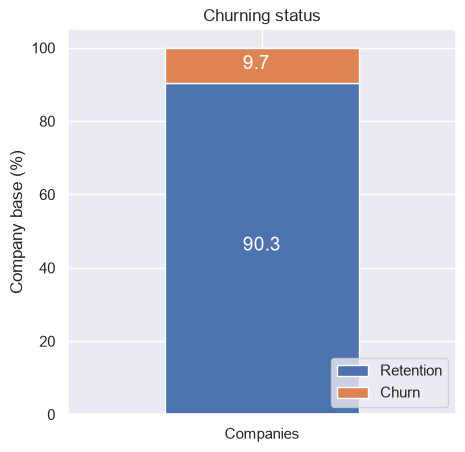

In [11]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

---


### 1. Consumptions

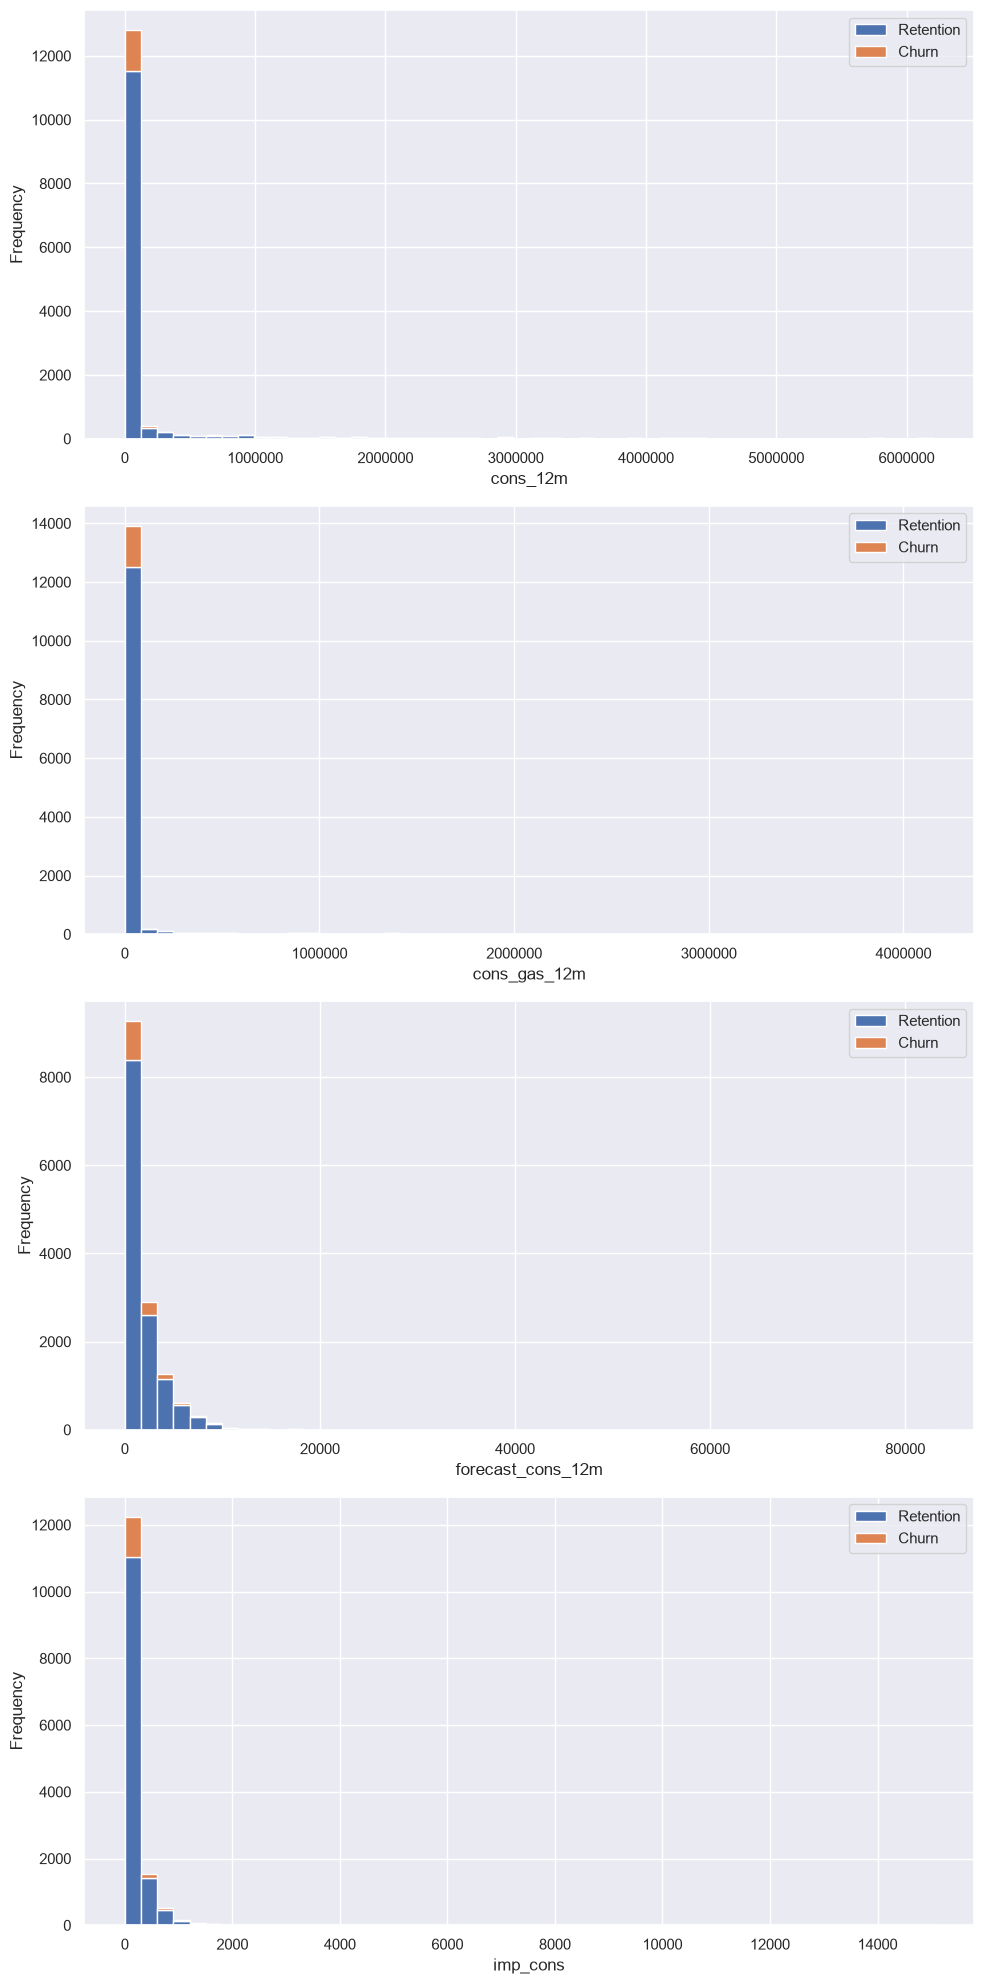

In [12]:
consumption_columns = ['cons_12m', 'cons_gas_12m', 'forecast_cons_12m', 'imp_cons']

# Creating subplots to display each distribution
fig, axes = plt.subplots(nrows=len(consumption_columns), ncols=1, figsize=(10, 20))

# To Iterate over each consumption-related column and plot its distribution based on churn
for i, column in enumerate(consumption_columns):
    plot_distribution(client_df, column, ax=axes[i])

plt.tight_layout()
plt.show()


### 2. Gross and Net Margin - overall client profitability.

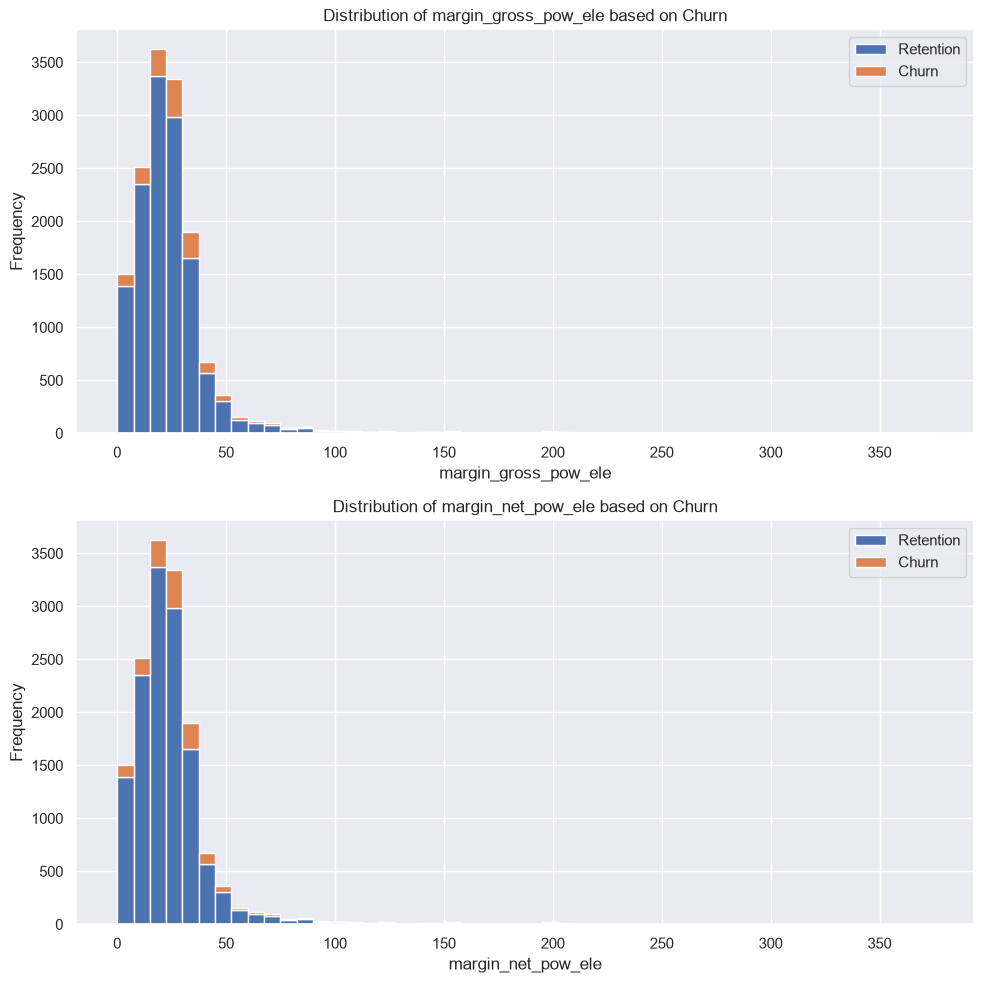

In [13]:
margin_columns = ['margin_gross_pow_ele', 'margin_net_pow_ele']

# Creating subplots to display each distribution
fig, axes = plt.subplots(nrows=len(margin_columns), ncols=1, figsize=(10, 10))

# To Iterate over each margin-related column and plot its distribution based on churn
for i, column in enumerate(margin_columns):
    plot_column_distribution(client_df, column, ax=axes[i])

plt.tight_layout()
plt.show()

### 3. Number of Products & Number of Years of Antiguitty -  client Loyalty.

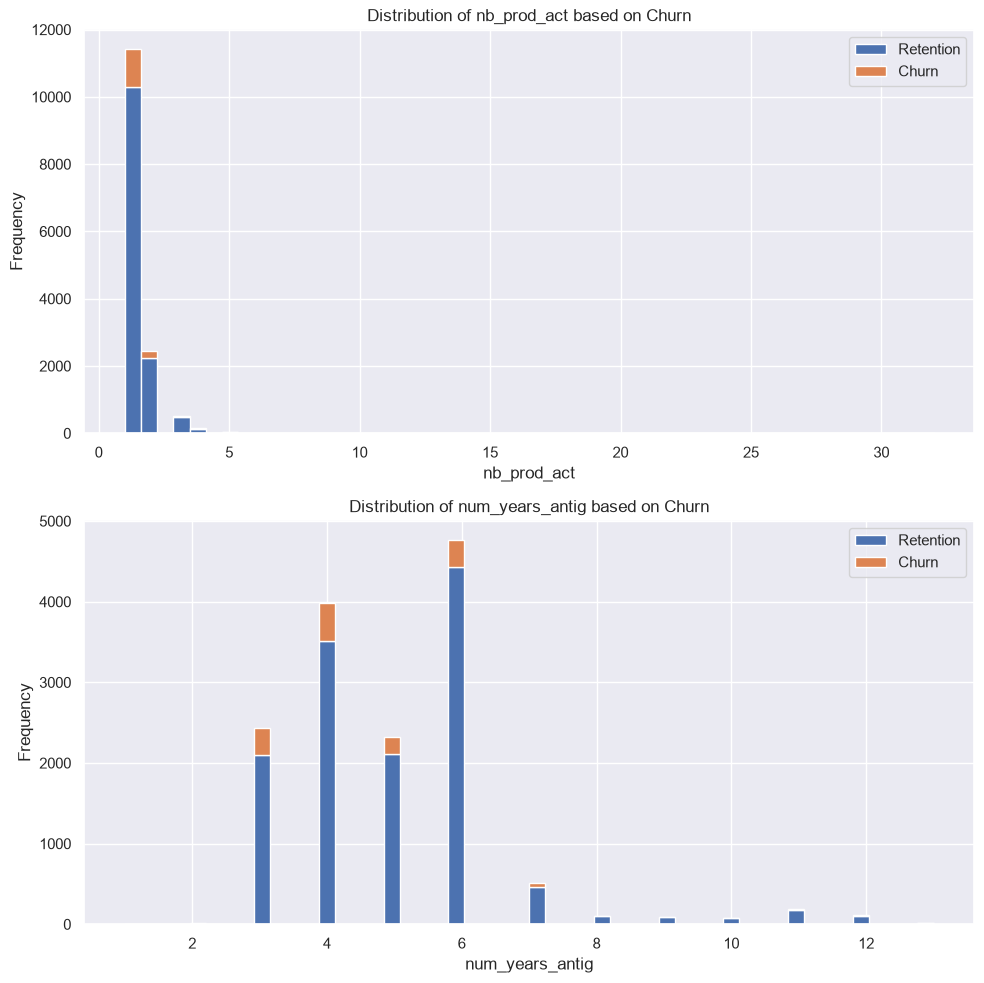

In [14]:
nbrod_and_antig_columns = ['nb_prod_act', 'num_years_antig']

# Creating subplots to display each distribution
fig, axes = plt.subplots(nrows=len(nbrod_and_antig_columns), ncols=1, figsize=(10, 10))

# To Iterate over each numerical column and plot its distribution based on churn
for i, column in enumerate(nbrod_and_antig_columns):
    plot_column_distribution(client_df, column, ax=axes[i])

plt.tight_layout()
plt.show()

### 4. Max Power consumption - energy needs or usage patterns of clients.

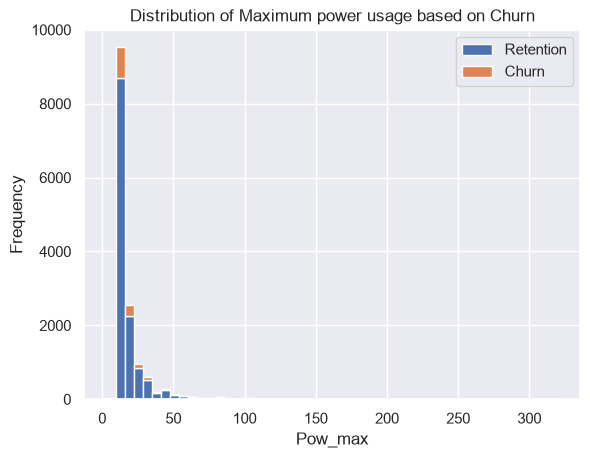

In [15]:
plot_column_distribution(client_df, 'pow_max', ax=plt.gca())
plt.title('Distribution of Maximum power usage based on Churn')
plt.xlabel('Pow_max')
plt.ylabel('Frequency')
plt.show()

### 5. Contract durations (difference between date_end and date_activ) - client Retention based on contract length

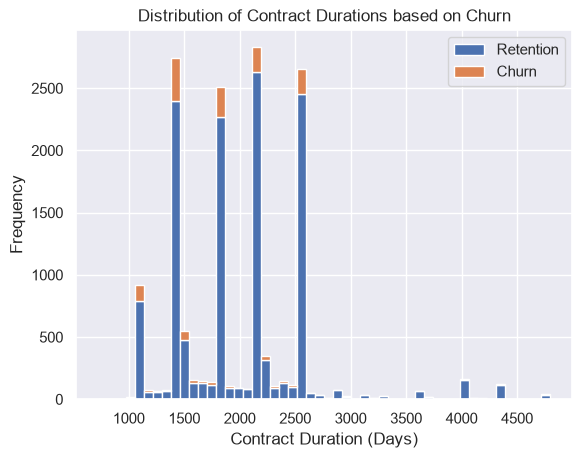

In [16]:
client_df['contract_duration'] = (pd.to_datetime(client_df['date_end']) - pd.to_datetime(client_df['date_activ'])).dt.days

# Plot the distribution of contract durations based on churn status
plot_column_distribution(client_df, 'contract_duration', ax=plt.gca())
plt.title('Distribution of Contract Durations based on Churn')
plt.xlabel('Contract Duration (Days)')
plt.ylabel('Frequency')
plt.show()

### 6. Sales Channel - effectiveness of different sales channels in retaining clients.

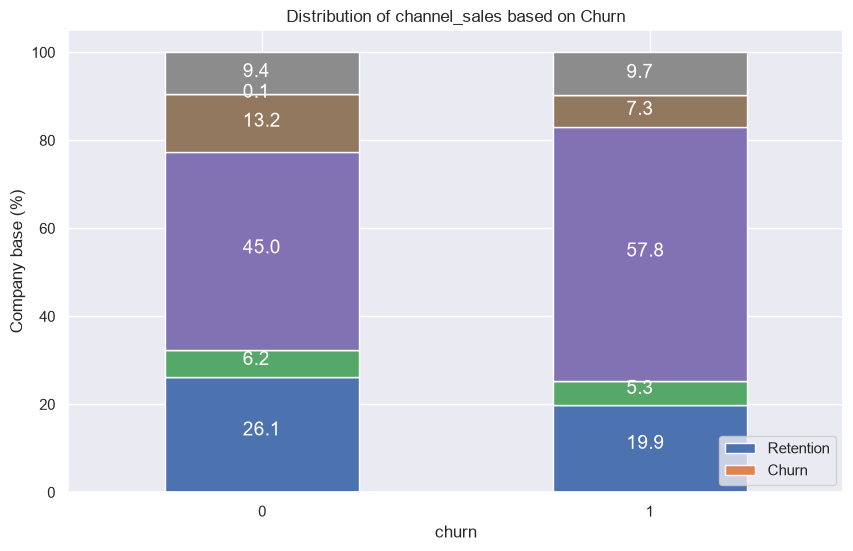

In [17]:
plot_categorical_column_churn(client_df, 'channel_sales')


---
## Price-sensitivity features & saving cleaned data

`price_data.csv` gives monthly off-peak/peak/mid-peak prices per client for 2015. For each client we compute the **variance** of each price component across the full year and across the second half of the year (Jul-Dec) — these `var_year_price_*` / `var_6m_price_*` columns are the price-sensitivity signal the rest of the pipeline is built around. We merge them onto `client_df` and write the result out as the input for feature engineering (notebook 02).

In [18]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')

price_cols = [
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'
]

# Variance of each price component per client, across the full year...
var_year = price_df.groupby('id')[price_cols].var()
var_year.columns = ['var_year_' + c for c in var_year.columns]

# ...and across the last 6 months only
price_df_h2 = price_df[price_df['price_date'].dt.month > 6]
var_6m = price_df_h2.groupby('id')[price_cols].var()
var_6m.columns = ['var_6m_' + c for c in var_6m.columns]

price_sensitivity = var_year.join(var_6m).reset_index()

# Combined (variable + fixed) variance per period
for period in ['off_peak', 'peak', 'mid_peak']:
    for window in ['year', '6m']:
        price_sensitivity[f'var_{window}_price_{period}'] = (
            price_sensitivity[f'var_{window}_price_{period}_var']
            + price_sensitivity[f'var_{window}_price_{period}_fix']
        )

price_sensitivity.head()

,id,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_year_price_off_peak,var_6m_price_off_peak,var_year_price_peak,var_6m_price_peak,var_year_price_mid_peak,var_6m_price_mid_peak
0,0002203ffbb812588b632b9e628cc38d,0.000016,0.000004,1.871602e-06,4.021438e-03,0.001448,0.000643,0.000011,0.000003,4.860000e-10,0.0,0.0,0.0,0.004037,0.000011,0.001452,0.000003,0.000645,4.860000e-10
1,0004351ebdd665e6ee664792efc4fd13,0.000005,0.000000,0.000000e+00,7.661891e-03,0.000000,0.000000,0.000003,0.000000,0.000000e+00,0.0,0.0,0.0,0.007667,0.000003,0.000000,0.000000,0.000000,0.000000e+00
2,0010bcc39e42b3c2131ed2ce55246e3c,0.000676,0.000000,0.000000e+00,5.965909e-01,0.000000,0.000000,0.000003,0.000000,0.000000e+00,0.0,0.0,0.0,0.597267,0.000003,0.000000,0.000000,0.000000,0.000000e+00
3,0010ee3855fdea87602a5b7aba8e42de,0.000025,0.000007,1.627620e-07,7.238536e-03,0.002606,0.001158,0.000011,0.000003,4.860000e-10,0.0,0.0,0.0,0.007264,0.000011,0.002613,0.000003,0.001158,4.860000e-10
4,00114d74e963e47177db89bc70108537,0.000005,0.000000,0.000000e+00,3.490909e-13,0.000000,0.000000,0.000003,0.000000,0.000000e+00,0.0,0.0,0.0,0.000005,0.000003,0.000000,0.000000,0.000000,0.000000e+00


In [19]:
client_df = client_df.merge(price_sensitivity, on='id')
print(client_df.shape)
client_df.head()

(14606, 45)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_year_price_off_peak,var_6m_price_off_peak,var_year_price_peak,var_6m_price_peak,var_year_price_mid_peak,var_6m_price_mid_peak
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,9.084737e-04,2.086294,99.530517,44.235794,1.102846,2.086425,4.955073e+01,9.953056e+01,22.022975,4.423670e+01
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0.009482,0.000000,0.000000,0.006470,0.009485,6.089453e-04,1.217891e-03,0.000000,0.000000e+00
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0.000000,0.000000,0.000000,0.007668,0.000004,2.558511e-07,9.450150e-08,0.000000,0.000000e+00
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0.000000,0.000000,0.000000,0.006470,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0.000000,0.000000,0.000000,0.005444,0.000011,1.957971e-03,2.896760e-06,0.000871,4.860000e-10


In [20]:
# contract_duration was only computed above for the distribution plot;
# leave it out of the saved dataset so this stays purely raw + price-sensitivity features
client_df.drop(columns=['contract_duration']).to_csv('../data/processed/clean_data_after_eda.csv', index=False)